# Experiment 9 - Introduction to Natural Language Processing

This notebook covers:
- Text Pre-processing (Tokenization, Stop-word Removal, Stemming)
- Word Embedding with Word2Vec
- Sentiment Classification using Average Vector + Naive Bayes
- Sentiment Classification using LSTM
- Sentiment Classification using BERT (Transformers)

## 0. Install Dependencies

In [ ]:
!pip install -U datasets transformers[torch] evaluate
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 114.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.8 MB/s eta 0:00:00


## 1. Load Dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset('MrbBakh/Sentiment140')
print(dataset)
print(dataset['train'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train.csv:   0%|          | 0.00/5.30M [00:00<?, ?B/s]

validation.csv:   0%|          | 0.00/661k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/663k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'date', 'user', 'sentiment', 'query', '__index_level_0__'],
        num_rows: 40000
    })
    validation: Dataset({
        features: ['text', 'date', 'user', 'sentiment', 'query', '__index_level_0__'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['text', 'date', 'user', 'sentiment', 'query', '__index_level_0__'],
        num_rows: 5000
    })
})
{'text': "Went to the park with my BFF. Wanted to get abducted by werewolves. Didn't happen. ", 'date': 'Sat Jun 06 20:15:20 PDT 2009', 'user': 'MelissaRM19', 'sentiment': 0, 'query': 'NO_QUERY', '__index_level_0__': 28821}


## 2. Text Pre-processing



### 2.1 Tokenization

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

def tokenize(row):
    tokens = word_tokenize(row['text'])
    # to lowercase and remove punctuation
    tokens = [token.lower() for token in tokens if token.isalpha()]
    return {'tokens': tokens}

dataset = dataset.map(tokenize)
print("Sample tokens:", dataset['train'][0]['tokens'])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Sample tokens: ['went', 'to', 'the', 'park', 'with', 'my', 'bff', 'wanted', 'to', 'get', 'abducted', 'by', 'werewolves', 'did', 'happen']


### 2.2 Stop-Words Removal

In [ ]:
from nltk.corpus import stopwords

nltk.download('stopwords')

def remove_stopwords(row):
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in row['tokens'] if token not in stop_words]
    return {'tokens': tokens}

dataset = dataset.map(remove_stopwords)
print("After stop-word removal:", dataset['train'][0]['tokens'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

After stop-word removal: ['went', 'park', 'bff', 'wanted', 'get', 'abducted', 'werewolves', 'happen']


### Task 1: Stemming with PorterStemmer

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_tokens(row):
    tokens = [stemmer.stem(token) for token in row['tokens']]
    return {'tokens': tokens}

dataset = dataset.map(stem_tokens)
print("After stemming:", dataset['train'][0]['tokens'])

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

After stemming: ['went', 'park', 'bff', 'want', 'get', 'abduct', 'werewolv', 'happen']


## 3. Word Embedding (Word2Vec)

In [ ]:
from gensim.models import Word2Vec

word_embedding = Word2Vec(
    dataset['train']['tokens'],
    vector_size=100,
    min_count=1,
    window=5,
    sg=1,
    hs=0,
    negative=10
)

word_embedding.save('w2v.model')
word_embedding = Word2Vec.load('w2v.model')

print("Vocab size:", len(word_embedding.wv))

# Check if 'happy' exists in the vocabulary before trying to access its embedding
if 'happy' in word_embedding.wv.key_to_index:
    print("Embedding for 'happy':", word_embedding.wv['happy'][:5], "...")
else:
    print("'happy' not found in vocabulary.")

Vocab size: 35593
'happy' not found in vocabulary.


## 4. Average Vector + Naive Bayes

### Task 2: Accuracy and Confusion Matrix on Test Set

In [ ]:
def filter_tokens(example):
    return {'tokens': [token for token in example['tokens'] if token in word_embedding.wv]}

def mean_vector(example):
    return {'mean': word_embedding.wv[example['tokens']].mean(axis=0)}

dataset = dataset.map(filter_tokens) \
                 .filter(lambda e: len(e['tokens']) > 0) \
                 .map(mean_vector)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/40000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/39924 [00:00<?, ? examples/s]

Map:   0%|          | 0/4963 [00:00<?, ? examples/s]

Map:   0%|          | 0/4966 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
from sklearn.naive_bayes import GaussianNB

X_train = np.array(dataset['train']['mean'])
y_train = np.array(dataset['train']['sentiment'])

clf = GaussianNB()
clf.fit(X_train, y_train)
print("Naive Bayes model trained.")

Naive Bayes model trained.


[Average Vector + NB] Test Accuracy: 0.6683


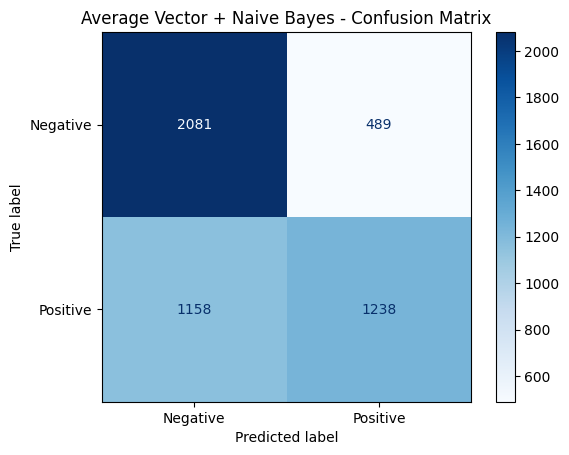

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_test = np.array(dataset['test']['mean'])
y_test = np.array(dataset['test']['sentiment'])

y_pred_nb = clf.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"[Average Vector + NB] Test Accuracy: {acc_nb:.4f}")

cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Average Vector + Naive Bayes - Confusion Matrix')
plt.show()

## 5. LSTM Model

In [ ]:
import torch
import torch.nn as nn

# Vectorize tokens
def vectorize(example):
    return {'vectors': word_embedding.wv[example['tokens']]}

dataset = dataset.map(vectorize)

Map:   0%|          | 0/39924 [00:00<?, ? examples/s]

Map:   0%|          | 0/4963 [00:00<?, ? examples/s]

Map:   0%|          | 0/4966 [00:00<?, ? examples/s]

### Task 3: Slice LSTM output to get last token's output for each sample in batch

In [ ]:
lstm = nn.LSTM(100, 200, batch_first=True)

batch = [torch.tensor(seq) for seq in dataset['train'][0:4]['vectors']]
padded_batch = nn.utils.rnn.pad_sequence(batch, batch_first=True)  # shape: (N, L, V)

out, _ = lstm(padded_batch)  # out shape: (N, L, H)
print("Full output shape:", out.shape)

# Task 3: Slice last token output for each sample
last_output = out[:, -1, :]  # shape: (N, H)
print("Last token output shape:", last_output.shape)

Full output shape: torch.Size([4, 8, 200])
Last token output shape: torch.Size([4, 200])


In [ ]:
# Prepare word-to-index mapping and padding
pad_vector = np.zeros(word_embedding.vector_size)
weights = np.vstack([word_embedding.wv.vectors, pad_vector])
vocab_size, embedding_size = weights.shape
pad_idx = vocab_size - 1

print(f"Vocab size (with pad): {vocab_size}, Embedding size: {embedding_size}")

def word_to_index(example):
    indices = [word_embedding.wv.key_to_index[token] for token in example['tokens']]
    return {'indices': indices}

dataset = dataset.map(word_to_index)

Vocab size (with pad): 35594, Embedding size: 100


Map:   0%|          | 0/39924 [00:00<?, ? examples/s]

Map:   0%|          | 0/4963 [00:00<?, ? examples/s]

Map:   0%|          | 0/4966 [00:00<?, ? examples/s]

In [ ]:
def pad_sequences(batch):
    indices = [torch.tensor(sample, dtype=torch.long) for sample in batch['indices']]
    indices = nn.utils.rnn.pad_sequence(indices, batch_first=True, padding_value=pad_idx)
    return {'indices': indices}

dataset = dataset.map(pad_sequences, batched=True, batch_size=None).with_format('torch')
print("Dataset formatted for PyTorch.")

Map:   0%|          | 0/39924 [00:00<?, ? examples/s]

Map:   0%|          | 0/4963 [00:00<?, ? examples/s]

Map:   0%|          | 0/4966 [00:00<?, ? examples/s]

Dataset formatted for PyTorch.


In [ ]:
import torch.nn.functional as F

class SentimentClassifierLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_size, hidden_size, num_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.lstm = nn.LSTM(embedding_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        embeddings = self.embedding(x)
        out, _ = self.lstm(embeddings)
        out = out[:, -1, :]       # last token output
        out = self.fc(out)
        out = torch.sigmoid(out)
        return out.squeeze(1)

hidden_size = 128
num_layers = 2

model = SentimentClassifierLSTM(
    vocab_size=vocab_size,
    embedding_size=embedding_size,
    hidden_size=hidden_size,
    num_layers=num_layers
)
model.embedding.weight = nn.Parameter(torch.FloatTensor(weights))
model.embedding.weight.requires_grad = False

learning_rate = 0.001
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = model.to(device)
criterion = criterion.to(device)

Using device: cuda


In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import torch

batch_size = 2048

def to_dataloader(ds_split, shuffle):
    # After dataset.map(pad_sequences, batched=True, batch_size=None).with_format('torch'),
    # ds_split['indices'] is a Column object containing individual padded tensors per sample.
    # ds_split['sentiment'] is a Column object containing individual sentiment values per sample.
    # We need to fully materialize these into single large tensors.

    # Collect individual tensors/scalars from the Column objects
    all_indices_list = [item for item in ds_split['indices']]
    all_sentiment_list = [item for item in ds_split['sentiment']]

    # Stack them to form single large tensors suitable for TensorDataset
    indices_tensor = torch.stack(all_indices_list)
    sentiment_tensor = torch.stack(all_sentiment_list).long() # Ensure sentiment is long type

    dataset_t = TensorDataset(indices_tensor, sentiment_tensor)
    return DataLoader(dataset_t, batch_size=batch_size, shuffle=shuffle)

train_dataloader      = to_dataloader(dataset['train'],      shuffle=True)
test_dataloader       = to_dataloader(dataset['test'],       shuffle=False)
validation_dataloader = to_dataloader(dataset['validation'], shuffle=False)

### Task 4: Train for 20 epochs with validation accuracy after each epoch

In [ ]:
def train_one_epoch(dataloader):
    model.train()
    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device).float()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def evaluate(dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = (outputs >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return accuracy_score(all_labels, all_preds)

num_epochs = 20
for epoch in range(1, num_epochs + 1):
    train_one_epoch(train_dataloader)
    val_acc = evaluate(validation_dataloader)
    print(f"Epoch {epoch:2d}/{num_epochs} — Validation Accuracy: {val_acc:.4f}")

Epoch  1/20 — Validation Accuracy: 0.5140
Epoch  2/20 — Validation Accuracy: 0.6349
Epoch  3/20 — Validation Accuracy: 0.6929
Epoch  4/20 — Validation Accuracy: 0.7135
Epoch  5/20 — Validation Accuracy: 0.7159
Epoch  6/20 — Validation Accuracy: 0.7211
Epoch  7/20 — Validation Accuracy: 0.7219
Epoch  8/20 — Validation Accuracy: 0.7215
Epoch  9/20 — Validation Accuracy: 0.7254
Epoch 10/20 — Validation Accuracy: 0.7276
Epoch 11/20 — Validation Accuracy: 0.7042
Epoch 12/20 — Validation Accuracy: 0.7300
Epoch 13/20 — Validation Accuracy: 0.7302
Epoch 14/20 — Validation Accuracy: 0.7332
Epoch 15/20 — Validation Accuracy: 0.7304
Epoch 16/20 — Validation Accuracy: 0.7161
Epoch 17/20 — Validation Accuracy: 0.7371
Epoch 18/20 — Validation Accuracy: 0.7356
Epoch 19/20 — Validation Accuracy: 0.7346
Epoch 20/20 — Validation Accuracy: 0.7296


### Task 5: Evaluate LSTM on Test Set

[LSTM] Test Accuracy: 0.7404


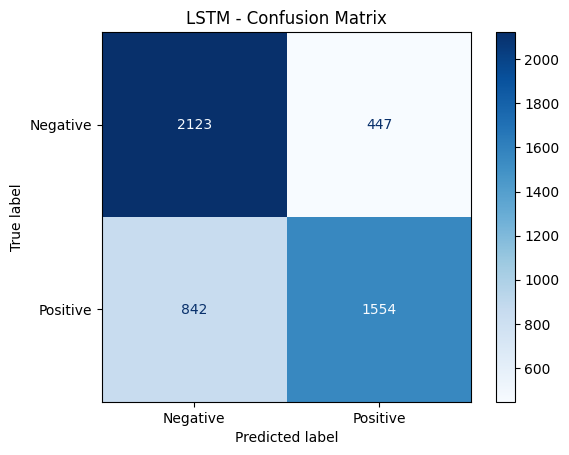

In [ ]:
model.eval()
all_preds_lstm, all_labels_lstm = [], []

with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = (outputs >= 0.5).long().cpu().numpy()
        all_preds_lstm.extend(preds)
        all_labels_lstm.extend(labels.numpy())

acc_lstm = accuracy_score(all_labels_lstm, all_preds_lstm)
print(f"[LSTM] Test Accuracy: {acc_lstm:.4f}")

cm_lstm = confusion_matrix(all_labels_lstm, all_preds_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('LSTM - Confusion Matrix')
plt.show()

### Task 6: Compare Average Vector vs LSTM

In [ ]:
print("=" * 40)
print(f"Average Vector + Naive Bayes Accuracy : {acc_nb:.4f}")
print(f"LSTM Accuracy                          : {acc_lstm:.4f}")
print("=" * 40)
print()
if acc_lstm > acc_nb:
    print(f"LSTM outperforms Naive Bayes by {acc_lstm - acc_nb:.4f}.")
    print("LSTM captures sequential/positional context; averaging loses word order.")
else:
    print("Naive Bayes matches or beats LSTM on this subset.")

Average Vector + Naive Bayes Accuracy : 0.6683
LSTM Accuracy                          : 0.7404

LSTM outperforms Naive Bayes by 0.0721.
LSTM captures sequential/positional context; averaging loses word order.


## 6. Transformers (BERT-mini)

### Task 7: Fine-tune BERT with validation accuracy

In [ ]:
from transformers import AutoTokenizer

# Reload the raw dataset to tokenize from original text
raw_dataset = load_dataset('MrbBakh/Sentiment140')

tokenizer = AutoTokenizer.from_pretrained('lyeonii/bert-mini')

tokenized_dataset = raw_dataset.map(
    lambda x: tokenizer(x['text'], padding=True, truncation=True, return_tensors='pt'),
    batched=True,
    batch_size=None
).with_format('torch')

tokenized_dataset = tokenized_dataset.rename_column('sentiment', 'labels')
print(tokenized_dataset)

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'date', 'user', 'labels', 'query', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 40000
    })
    validation: Dataset({
        features: ['text', 'date', 'user', 'labels', 'query', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['text', 'date', 'user', 'labels', 'query', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
})


In [ ]:
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained('lyeonii/bert-mini', num_labels=2)

pytorch_model.bin:   0%|          | 0.00/44.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: lyeonii/bert-mini
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import evaluate as hf_evaluate
import numpy as np

accuracy_metric = hf_evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='sentiment-analysis',
    num_train_epochs=3,
    per_device_train_batch_size=512,
    per_device_eval_batch_size=512,
    weight_decay=0.01,
    eval_strategy='epoch',       # was evaluation_strategy
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    compute_metrics=compute_metrics
)

trainer.train()

model.safetensors:   0%|          | 0.00/44.7M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy
1,0.594648,0.498102,0.762800
2,0.486107,0.468817,0.781200
3,0.461921,0.462445,0.786600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=237, training_loss=0.5142251509654371, metrics={'train_runtime': 181.3525, 'train_samples_per_second': 661.695, 'train_steps_per_second': 1.307, 'total_flos': 371618841600000.0, 'train_loss': 0.5142251509654371, 'epoch': 3.0})

### Task 8: Evaluate BERT on Test Set

[BERT-mini] Test Accuracy: 0.7918


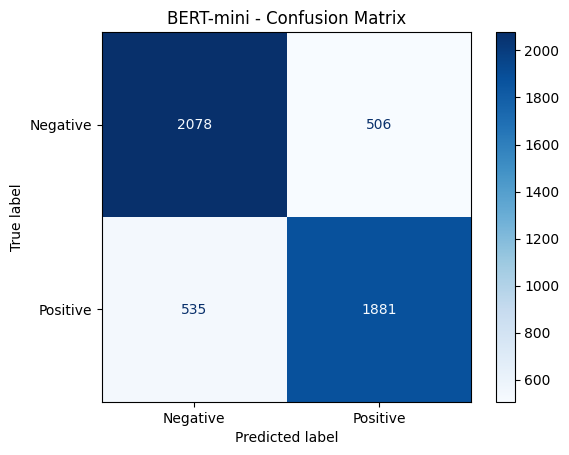

In [ ]:
test_results = trainer.predict(tokenized_dataset['test'])

bert_preds = np.argmax(test_results.predictions, axis=-1)
bert_labels = test_results.label_ids

acc_bert = accuracy_score(bert_labels, bert_preds)
print(f"[BERT-mini] Test Accuracy: {acc_bert:.4f}")

cm_bert = confusion_matrix(bert_labels, bert_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('BERT-mini - Confusion Matrix')
plt.show()

### Task 9: Compare All Three Models

In [ ]:

print("=" * 50)
print("         Final Model Comparison (Test Set)")
print("=" * 50)
print(f"  Average Vector + Naive Bayes : {acc_nb:.4f}")
print(f"  LSTM (2-layer, Word2Vec)     : {acc_lstm:.4f}")
print(f"  BERT-mini (fine-tuned)       : {acc_bert:.4f}")
print("=" * 50)
print()
print("Analysis:")
print("- Naive Bayes with average vectors loses word order (e.g., negation).")
print("- LSTM preserves sequential context, improving over the bag-of-words baseline.")
print("- BERT-mini uses bidirectional attention and pre-trained contextual embeddings,")
print("  capturing long-range dependencies and generally achieving the best accuracy.")

         Final Model Comparison (Test Set)
  Average Vector + Naive Bayes : 0.6683
  LSTM (2-layer, Word2Vec)     : 0.7404
  BERT-mini (fine-tuned)       : 0.7918

Analysis:
- Naive Bayes with average vectors loses word order (e.g., negation).
- LSTM preserves sequential context, improving over the bag-of-words baseline.
- BERT-mini uses bidirectional attention and pre-trained contextual embeddings,
  capturing long-range dependencies and generally achieving the best accuracy.
